In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import neighbors, datasets
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score


We use KNN in order to achieve two main objectives:
- Classificate, which means we have to know in which group something belong to.
- Regression, which means that it's useful to predict a numeric value. 

Examples about classification:
- If the 5 incidents that are similar to the new one were "Ransomware", KNN will cassificate it as  "Ransomware".
- We can use it to predict if an attack will have a impact of High Severity” or “Low Severity” impact, based on the number of compromised records and the company's industry sector.

Examples about Regression:
- How much money will a company with 500 employees lose? --> KNN finds similar companies and calculates the average of their losses.
- Predict total_loss_usd based on the similarity to other past attacks.

We have to scale the dataset before using KNN (codigo de como se escala, pero luego abajo no se utiliza )

In [2]:
finantial = pd.read_csv("data/raw/financial_impact.csv")
master = pd.read_csv("data/raw/incidents_master.csv")
market = pd.read_csv("data/raw/market_impact.csv")

from sklearn.preprocessing import StandardScaler
import pandas as pd
df_total = master.merge(finantial, on='incident_id').merge(market, on='incident_id')

features = ['company_revenue_usd', 'employee_count', 'data_compromised_records', 'downtime_hours']
X = df_total[features].fillna(0) # Limpieza rápida de nulos

# 2. Inicializar el escalador Z-score
scaler = StandardScaler()

# 3. Ajustar y transformar (esto calcula media/desviación y escala)
X_scaled = scaler.fit_transform(X)

# Ahora X_scaled es un array donde todos los valores están "en la misma escala"
# Este es el objeto que le pasas al KNN
print("Media de las columnas escaladas (debe ser casi 0):", X_scaled.mean(axis=0))
print("Desviación de las columnas escaladas (debe ser 1):", X_scaled.std(axis=0))

Media de las columnas escaladas (debe ser casi 0): [ 3.77948264e-17  0.00000000e+00 -1.34981523e-17 -2.69963046e-17]
Desviación de las columnas escaladas (debe ser 1): [1. 1. 1. 1.]


Confusion matrix (High severity)

In [13]:
df = master.merge(finantial, on='incident_id')

# 1 si la pérdida es mayor a la media (Gravedad Alta), 0 si es menor (Baja)
mean_loss = df['total_loss_usd'].median()
df['High_severity'] = (df['total_loss_usd'] > mean_loss).astype(int)


features = ['company_revenue_usd', 'employee_count', 'data_compromised_records', 'downtime_hours']
X = df[features].fillna(0) # Tratamos nulos básicos
y = df['High_severity']

# 3. ESCALADO DE DATOS (Paso Crítico para KNN)
# Como viste en tus apuntes, KNN usa distancias. 
# Sin escalar, 'revenue' dominaría a 'downtime'.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

knn = KNeighborsClassifier(n_neighbors=13, weights='distance')
knn.fit(X_train, y_train)

predicciones = knn.fit(X_train, y_train).predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, predicciones))
print("\nReport about the classification:")
print(classification_report(y_test, predicciones))

Confusion Matrix:
[[69 42]
 [64 59]]

Report about the classification:
              precision    recall  f1-score   support

           0       0.52      0.62      0.57       111
           1       0.58      0.48      0.53       123

    accuracy                           0.55       234
   macro avg       0.55      0.55      0.55       234
weighted avg       0.55      0.55      0.55       234



Confusion matrix (TARGET)

In [14]:
df_total = master.merge(finantial, on='incident_id').merge(market, on='incident_id')

# Definimos "Gravedad Alta" (1) si la pérdida es mayor a la mediana
df_total['target'] = (df_total['total_loss_usd'] > df_total['total_loss_usd'].median()).astype(int)

# 2. Selección de variables y Escalado Z-score
features = ['company_revenue_usd', 'employee_count', 'data_compromised_records', 'downtime_hours']
X = df_total[features].fillna(0)
y = df_total['target']


# 3. ESCALADO DE DATOS (Paso Crítico para KNN)
# Como viste en tus apuntes, KNN usa distancias. 
# Sin escalar, 'revenue' dominaría a 'downtime'.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

knn = KNeighborsClassifier(n_neighbors=30, weights='distance')
knn.fit(X_train, y_train)

predicciones = knn.fit(X_train, y_train).predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, predicciones))
print("\nReport about the classification:")
print(classification_report(y_test, predicciones))

Confusion Matrix:
[[18 34]
 [19 28]]

Report about the classification:
              precision    recall  f1-score   support

           0       0.49      0.35      0.40        52
           1       0.45      0.60      0.51        47

    accuracy                           0.46        99
   macro avg       0.47      0.47      0.46        99
weighted avg       0.47      0.46      0.46        99



The first important plot (TARGET)

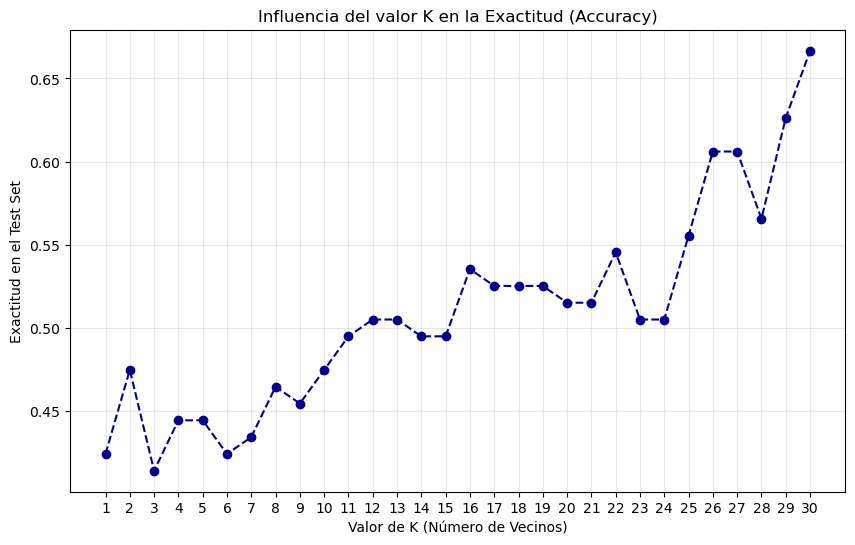

In [5]:
df_total = master.merge(finantial, on='incident_id').merge(market, on='incident_id')

# Definimos "Gravedad Alta" (1) si la pérdida es mayor a la mediana
df_total['target'] = (df_total['total_loss_usd'] > df_total['total_loss_usd'].median()).astype(int)

# 2. Selección de variables y Escalado Z-score
features = ['company_revenue_usd', 'employee_count', 'data_compromised_records', 'downtime_hours']
X = df_total[features].fillna(0)
y = df_total['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# 4. Probar diferentes valores de K
k_range = range(1, 31)
accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

# 5. Crear el Plot
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o', linestyle='--', color='darkblue')
plt.title('Influencia del valor K en la Exactitud (Accuracy)')
plt.xlabel('Valor de K (Número de Vecinos)')
plt.ylabel('Exactitud en el Test Set')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.savefig('knn_accuracy_k.png')

The second important plot (HIGH SEVERITY)

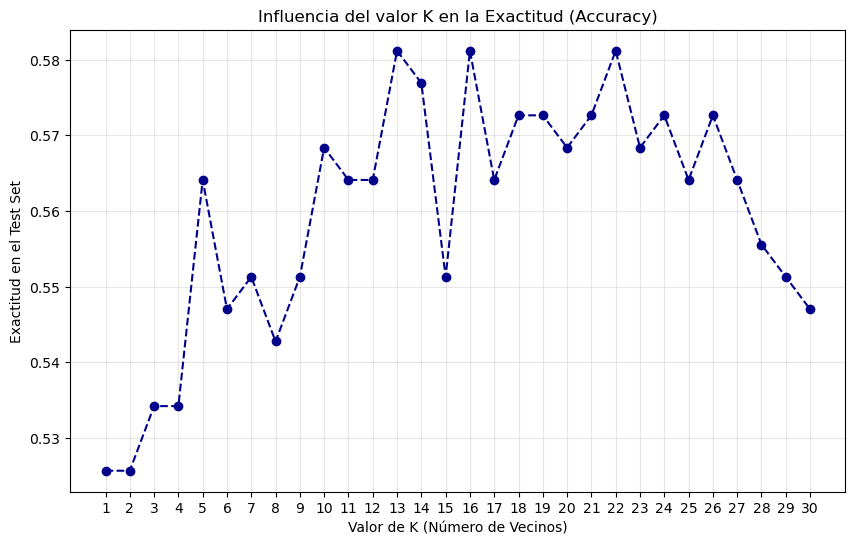

In [6]:
df_total = master.merge(finantial, on='incident_id').merge(market, on='incident_id')

mean_loss = df['total_loss_usd'].median()
df['High_severity'] = (df['total_loss_usd'] > mean_loss).astype(int)

features = ['company_revenue_usd', 'employee_count', 'data_compromised_records', 'downtime_hours']
X = df[features].fillna(0) # Tratamos nulos básicos
y = df['High_severity']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# 4. Probar diferentes valores de K
k_range = range(1, 31)
accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

# 5. Crear el Plot
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o', linestyle='--', color='darkblue')
plt.title('Influencia del valor K en la Exactitud (Accuracy)')
plt.xlabel('Valor de K (Número de Vecinos)')
plt.ylabel('Exactitud en el Test Set')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.savefig('knn_accuracy_k.png')

ACCURACY vs RECALL??? IMPORTANT? (TARGET)

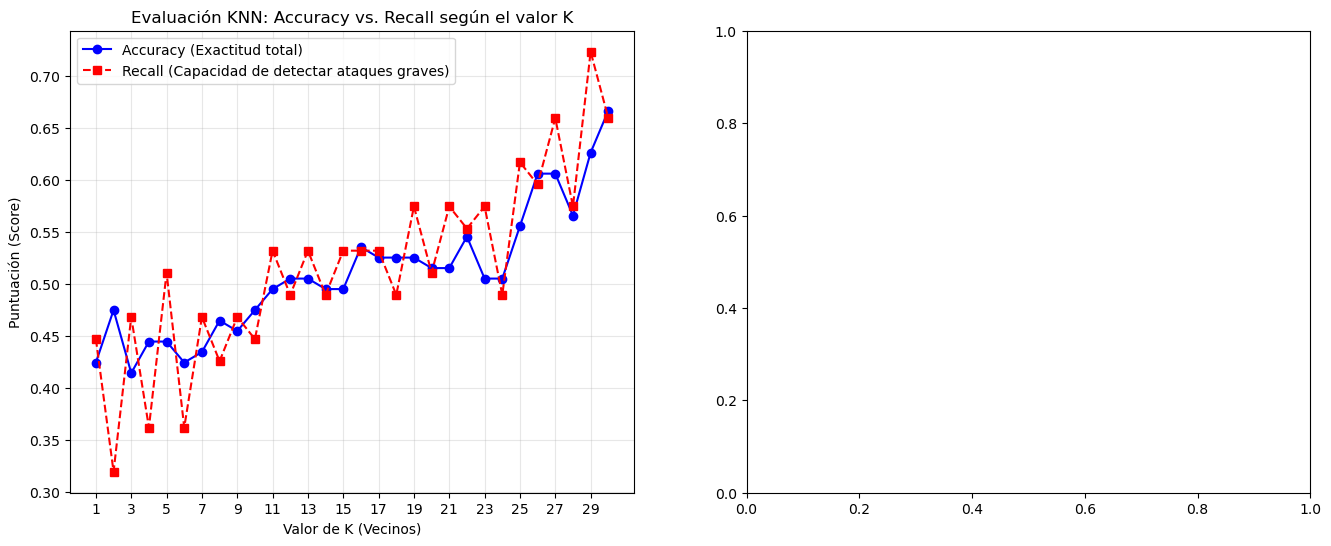

In [8]:
df_total = master.merge(finantial, on='incident_id').merge(market, on='incident_id')

# Definir el Target (1 = Alta gravedad en pérdidas, 0 = Baja)
df_total['target'] = (df_total['total_loss_usd'] > df_total['total_loss_usd'].median()).astype(int)

# 2. Selección de Features y Escalado Z-Score (Obligatorio)
features = ['company_revenue_usd', 'employee_count', 'data_compromised_records', 'downtime_hours']
X = df_total[features].fillna(0)
y = df_total['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# 3. Calcular Métricas para un rango de K (1 a 30)
k_range = range(1, 31)
accuracies = []
recalls = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    accuracies.append(accuracy_score(y_test, y_pred))
    recalls.append(recall_score(y_test, y_pred)) # Mide los falsos negativos

# 4. GENERAR LOS PLOTS (Diagnóstico del Modelo)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Accuracy vs Recall
ax1.plot(k_range, accuracies, marker='o', linestyle='-', color='blue', label='Accuracy (Exactitud total)')
ax1.plot(k_range, recalls, marker='s', linestyle='--', color='red', label='Recall (Capacidad de detectar ataques graves)')
ax1.set_title('Evaluación KNN: Accuracy vs. Recall según el valor K')
ax1.set_xlabel('Valor de K (Vecinos)')
ax1.set_ylabel('Puntuación (Score)')
ax1.set_xticks(np.arange(1, 31, 2))
ax1.grid(True, alpha=0.3)
ax1.legend()

HIGH VARIANCE

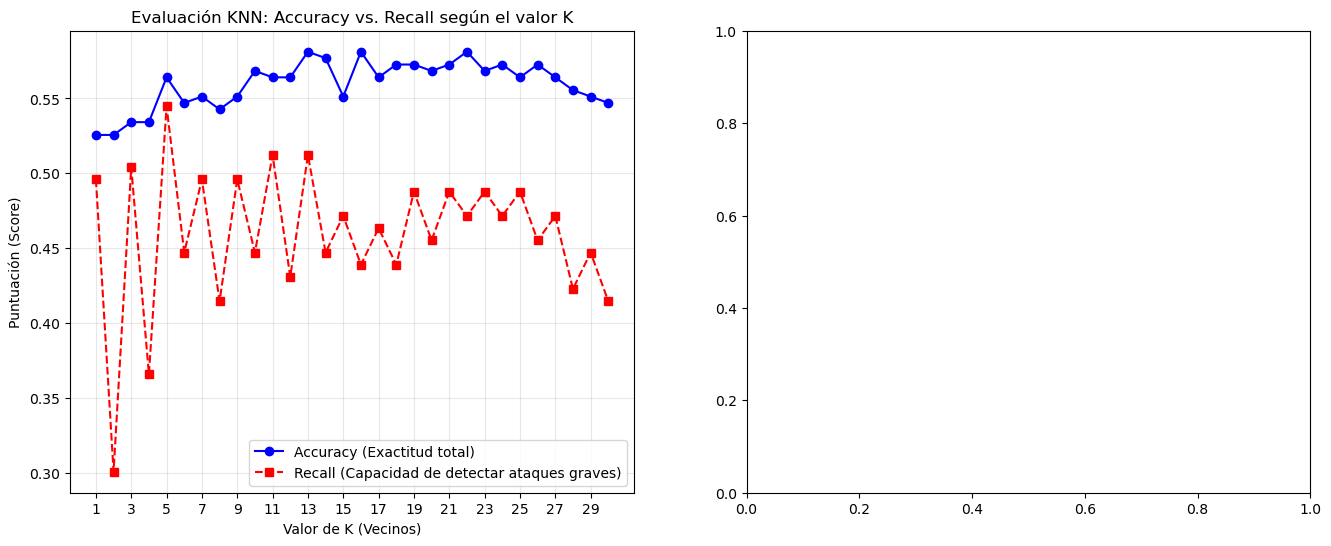

In [15]:
df_total = master.merge(finantial, on='incident_id').merge(market, on='incident_id')

mean_loss = df['total_loss_usd'].median()
df['High_severity'] = (df['total_loss_usd'] > mean_loss).astype(int)

features = ['company_revenue_usd', 'employee_count', 'data_compromised_records', 'downtime_hours']
X = df[features].fillna(0) # Tratamos nulos básicos
y = df['High_severity']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# 3. Calcular Métricas para un rango de K (1 a 30)
k_range = range(1, 31)
accuracies = []
recalls = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    accuracies.append(accuracy_score(y_test, y_pred))
    recalls.append(recall_score(y_test, y_pred)) # Mide los falsos negativos

# 4. GENERAR LOS PLOTS (Diagnóstico del Modelo)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Accuracy vs Recall
ax1.plot(k_range, accuracies, marker='o', linestyle='-', color='blue', label='Accuracy (Exactitud total)')
ax1.plot(k_range, recalls, marker='s', linestyle='--', color='red', label='Recall (Capacidad de detectar ataques graves)')
ax1.set_title('Evaluación KNN: Accuracy vs. Recall según el valor K')
ax1.set_xlabel('Valor de K (Vecinos)')
ax1.set_ylabel('Puntuación (Score)')
ax1.set_xticks(np.arange(1, 31, 2))
ax1.grid(True, alpha=0.3)
ax1.legend()